# CloudGripper workspace_mapping Workflow

This notebook is designed for the `cloudgripper-api` repository and assumes:
- `calibration/` was copied into `cloudgripper-api/`
- `rgmc_cloud_robotics_2026` is available next to `cloudgripper-api`
- preprocessing order must remain fixed
- the same detector is used during calibration and inference

In [1]:
import os
import sys

import os
import sys

print("cwd:", os.getcwd())

# 현재 폴더 자체가 cloudgripper-api
cloudgripper_root = os.path.abspath(".")

# RGMC 아래의 다른 repo
rgmc_src = os.path.abspath("../rgmc_cloud_robotics_2026/src")

print("cloudgripper_root:", cloudgripper_root, os.path.exists(cloudgripper_root))
print("client dir exists:", os.path.exists(os.path.join(cloudgripper_root, "client")))
print("cloudgripper_client.py exists:", os.path.exists(os.path.join(cloudgripper_root, "client", "cloudgripper_client.py")))
print("rgmc_src:", rgmc_src, os.path.exists(rgmc_src))

for p in [cloudgripper_root, rgmc_src]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.append(p)
        print("added:", p)

from client.cloudgripper_client import GripperRobot
from rgmc_cloud_robotics_2026.calib_fisheye_cam import undistort_image

print("all imports success")

cwd: /Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks
cloudgripper_root: /Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks True
client dir exists: False
cloudgripper_client.py exists: False
rgmc_src: /Users/kimsumin/projects/RGMC/cloudgripper-api/rgmc_cloud_robotics_2026/src False
added: /Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks


ModuleNotFoundError: No module named 'client'

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/kimsumin/projects/RGMC")

print("cwd:", os.getcwd())
print("PROJECT_ROOT:", PROJECT_ROOT)

cwd: /Users/kimsumin/projects/RGMC/cloudgripper-api
PROJECT_ROOT: /Users/kimsumin/projects/RGMC


In [3]:
import cv2
import yaml
import numpy as np
import pandas as pd

from client.cloudgripper_client import GripperRobot
from rgmc_cloud_robotics_2026.calib_fisheye_cam import undistort_image

from calibration.config import calibration_config_from_yaml
from calibration.camera_utils import load_camera_params, get_processed_base_image
from calibration.detector import YOLOGripperDetector
from calibration.collector import collect_calibration
from calibration.build_lookup_table import parse_dataset, build_bidirectional_lookup, save_lookup_table
from calibration.pixel_to_workspace import PixelToWorkspaceMapper
from calibration.visualize_workspace_grid import draw_grid_overlay, load_lut
from calibration.notebook_helpers import show_bgr, load_csv_preview, list_failed_points

## 1. Robot connection

Set your robot name and API token.

In [4]:
ROBOT_NAME = "robot6"
TOKEN = os.environ.get("CLOUDGRIPPER_TOKEN", "DBlhGCRsba1HPDBkhvg6qLMMq44IltNi")
robot = GripperRobot(ROBOT_NAME, TOKEN)
state, t = robot.get_state()
print(state)

{'x_norm': 0.10321428571428563, 'y_norm': 0.7028571428571428, 'z_norm': 0.09999999999999998, 'rotation': 0, 'claw_norm': 0.0, 'z_current': '0.00', 'rotation_current': '0.02', 'claw_current': '0.04'}


In [5]:
CONFIG_PATH = PROJECT_ROOT / "cloudgripper-api" / "notebooks" / "examples" / "my_config_robot6_notebook.yaml"

print(CONFIG_PATH)
print(CONFIG_PATH.exists())

/Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks/examples/my_config_robot6_notebook.yaml
True


## 2. Load YAML config and camera parameters

In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/kimsumin/projects/RGMC")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("exists:", PROJECT_ROOT.exists())

CONFIG_PATH = PROJECT_ROOT / "cloudgripper-api" / "notebooks" / "examples" / "my_config_robot6_notebook.yaml"

config = calibration_config_from_yaml(str(CONFIG_PATH))

CAMERA_YAML = Path(config.camera_params_file)
if not CAMERA_YAML.is_absolute():
    CAMERA_YAML = (CONFIG_PATH.parent / CAMERA_YAML).resolve()

print("CAMERA_YAML:", CAMERA_YAML)
print("exists:", CAMERA_YAML.exists())

K, D = load_camera_params(str(CAMERA_YAML))
config

PROJECT_ROOT: /Users/kimsumin/projects/RGMC
exists: True
CAMERA_YAML: /Users/kimsumin/projects/RGMC/rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr06.yaml
exists: True


CalibrationConfig(grid_size=33, x_min=0.0, x_max=0.95, y_min=0.0, y_max=1.0, frames_per_point=5, settle_time_sec=0.7, inter_frame_sec=0.05, reverse_xy=False, resume=True, save_masks=True, write_debug_json=True, output_subdir='rope_calibration', custom_points=None, camera_params_file='../../../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr06.yaml', planar_only=True, prefer_raw_base_image=True, min_valid_frames=3, aggregate_mode='median', detector_lower_hsv=[10, 120, 120], detector_upper_hsv=[15, 255, 255], detector_kernel_size=5, detector_min_area=100)

In [7]:

from pathlib import Path

print("CONFIG_PATH:", CONFIG_PATH)
print("CONFIG_PATH resolved:", Path(CONFIG_PATH).resolve())

config = calibration_config_from_yaml(str(CONFIG_PATH))
print("camera_params_file:", config.camera_params_file)
print("exists:", Path(config.camera_params_file).exists())

CONFIG_PATH: /Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks/examples/my_config_robot6_notebook.yaml
CONFIG_PATH resolved: /Users/kimsumin/projects/RGMC/cloudgripper-api/notebooks/examples/my_config_robot6_notebook.yaml
camera_params_file: ../../../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr06.yaml
exists: False


In [8]:

def process_calibration_proc_from_raw(img_raw, K, D, undistort_image_fn):
    """Calibration / runtime 공통 proc 기준: undistort only."""
    img_proc = undistort_image_fn(K, D, img_raw)
    if isinstance(img_proc, tuple):
        img_proc = img_proc[0]
    if not isinstance(img_proc, np.ndarray):
        raise TypeError(f"Expected np.ndarray proc image, got {type(img_proc)}")
    return img_proc

def get_same_frame_raw_and_proc(robot, K, D, undistort_image_fn):
    """카메라를 한 번만 읽고, 같은 raw 프레임에서 proc를 만든다."""
    raw_out = robot.getImageBase()
    if isinstance(raw_out, tuple):
        img_raw, ts_img = raw_out
    else:
        img_raw, ts_img = raw_out, None

    if not isinstance(img_raw, np.ndarray):
        raise TypeError(f"Expected np.ndarray raw image, got {type(img_raw)}")

    img_proc = process_calibration_proc_from_raw(img_raw, K, D, undistort_image_fn)
    return img_raw, img_proc, ts_img

def get_state_with_timestamp(robot):
    state_out = robot.get_state()
    if isinstance(state_out, tuple):
        state, ts_state = state_out
    else:
        state, ts_state = state_out, None

    if not isinstance(state, dict):
        raise TypeError(f"Expected dict state, got {type(state)}")

    return state, ts_state

def get_state_xy(robot):
    state, ts_state = get_state_with_timestamp(robot)
    x_state = state.get("x", state.get("x_norm"))
    y_state = state.get("y", state.get("y_norm"))

    if x_state is None or y_state is None:
        raise KeyError("State does not contain x/y or x_norm/y_norm")

    return float(x_state), float(y_state), ts_state, state

ROBOT_ID = "".join(ch for ch in ROBOT_NAME if ch.isdigit()) or ROBOT_NAME
ARTIFACT_PREFIX = f"robot{ROBOT_ID}"

def make_artifact_paths(output_dir):
    output_dir = Path(output_dir)
    return {
        "dir": output_dir,
        "csv": output_dir / "calibration.csv",
        "failed_csv": output_dir / "calibration_failed.csv",
        "lut_pkl": output_dir / "lut.pkl",
        "summary_json": output_dir / "summary.json",
        "images_dir": output_dir / "images",
    }

print("ROBOT_ID:", ROBOT_ID)
print("ARTIFACT_PREFIX:", ARTIFACT_PREFIX)


ROBOT_ID: 6
ARTIFACT_PREFIX: robot6


## 3. Detector sanity check on one current frame

{'ok': True, 'center_uv': (261.5135363790186, 82.05076142131979), 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'contour': array([[[253,  62]],

       [[253,  66]],

       [[247,  72]],

       [[247,  73]],

       [[246,  74]],

       [[242,  74]],

       [[242,  88]],

       [[245,  88]],

       [[247,  90]],

       [[247,  91]],

       [[248,  92]],

       [[248,  93]],

       [[253,  98]],

       [[253, 101]],

       [[271, 101]],

       [[271,  98]],

       [[274,  95]],

       [[275,  95]],

       [[276,  94]],

       [[276,  93]],

       [[278,  91]],

       [[281,  91]],

       [[281,  77]],

       [[278,  77]],

       [[276,  75]],

       [[276,  74]],

       [[274,  72]],

       [[274,  71]],

       [[269,  66]],

       [[269,  62]]], dtype=int32), 'score': 0.77218729257

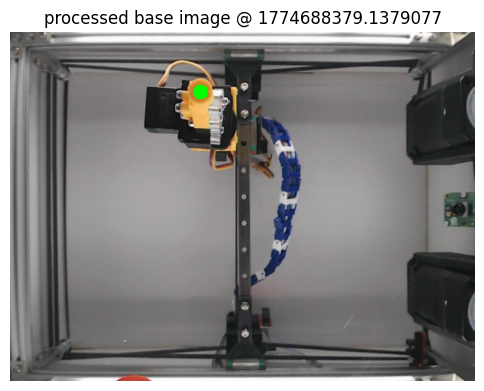

ok: True
center_uv: (261.5135363790186, 82.05076142131979)
score: 0.7721872925758362
bbox_xyxy: (245.95706176757812, 65.25611877441406, 278.2283020019531, 100.22126770019531)


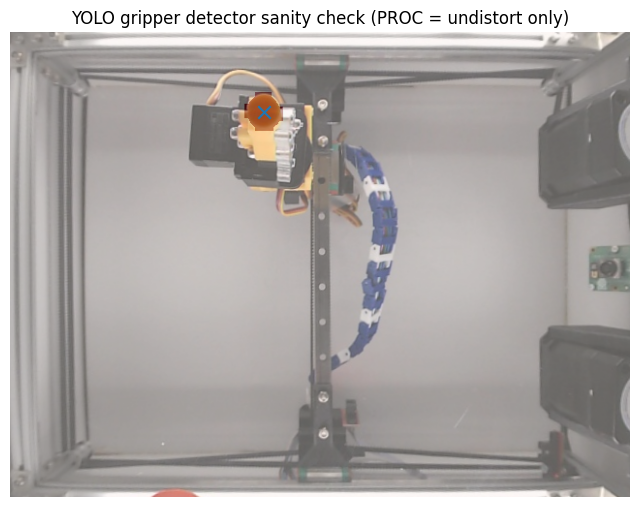

In [9]:
import matplotlib.pyplot as plt

MODEL_PATH = PROJECT_ROOT / "cloudgripper-api" / "calibration" / "Arm_detecter" / "last.pt"

detector = YOLOGripperDetector(
    model_path=str(MODEL_PATH),
    conf=0.25,
    min_area=100,
    target_class=None,
    prefer_center=True,
)

img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
processed_img = img_proc

pred = detector.predict(processed_img)
vis = processed_img.copy()

if pred.get("ok") and pred.get("center_uv") is not None:
    u, v = pred["center_uv"]
    cv2.circle(vis, (int(round(u)), int(round(v))), 10, (0, 255, 0), -1)

print(pred)
show_bgr(vis, title=f"processed base image @ {ts}")

print("ok:", pred.get("ok"))
print("center_uv:", pred.get("center_uv"))
print("score:", pred.get("score"))
print("bbox_xyxy:", pred.get("bbox_xyxy"))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))

if pred.get("ok") and pred.get("mask") is not None:
    plt.imshow(pred["mask"], alpha=0.35, cmap="Reds")

if pred.get("ok") and pred.get("center_uv") is not None:
    u, v = pred["center_uv"]
    plt.scatter([u], [v], s=80, marker="x")

plt.title("YOLO gripper detector sanity check (PROC = undistort only)")
plt.axis("off")
plt.show()

## 4. Optional corner / sanity moves

In [25]:
test_points = [
    (1.0, 0.0),
    (1.0, 1.0),
    (0.0, 1.0),
    (0.0, 0.0),
]

Move to (1.00, 0.00)


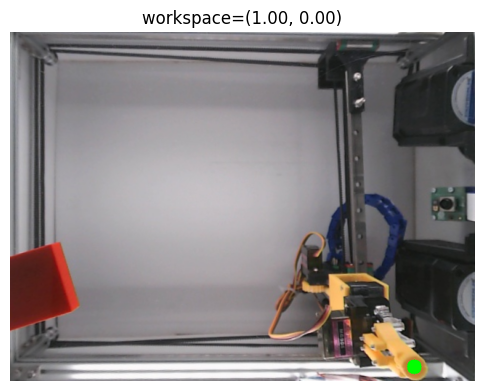

Move to (1.00, 1.00)


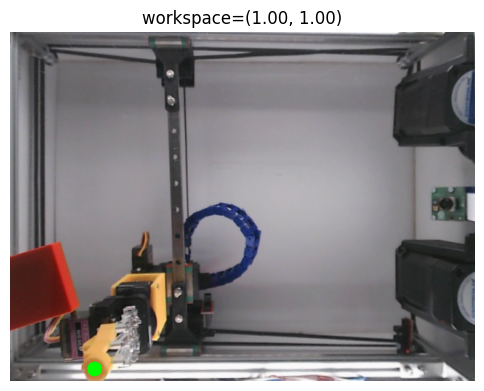

Move to (0.00, 1.00)


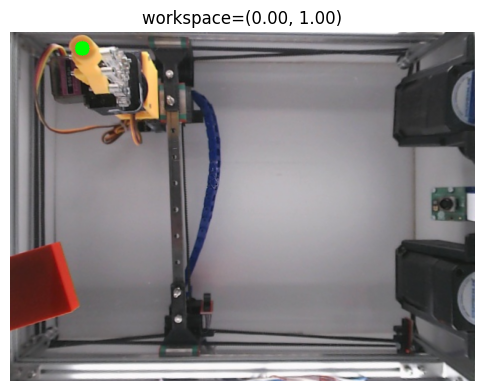

Move to (0.00, 0.00)


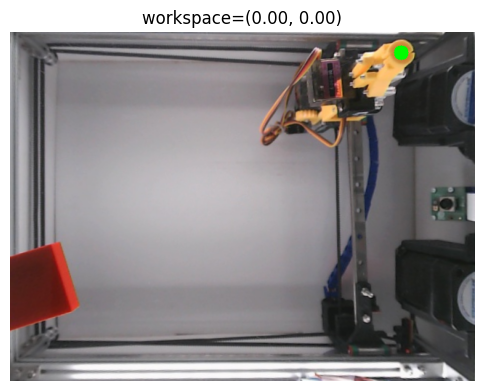

In [26]:
import time

results = []
for x, y in test_points:
    print(f"Move to ({x:.2f}, {y:.2f})")
    robot.move_xy(x, y)
    time.sleep(1.5)

    img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
    pred = detector.predict(img_proc)

    results.append({"x": x, "y": y, "pred": pred, "ts": ts})
    vis = img_proc.copy()

    if pred.get("ok") and pred.get("center_uv") is not None:
        u, v = pred["center_uv"]
        cv2.circle(vis, (int(round(u)), int(round(v))), 10, (0, 255, 0), -1)

    show_bgr(vis, title=f"workspace=({x:.2f}, {y:.2f})")

results

## 5. Collect calibration data

Choose an output directory under `cloudgripper-api/`.

In [38]:
OUTPUT_DIR = PROJECT_ROOT / "calibration_data" / ARTIFACT_PREFIX

ARTIFACT_PATHS = make_artifact_paths(OUTPUT_DIR)
CALIBRATION_CSV = ARTIFACT_PATHS["csv"]
FAILED_CSV = ARTIFACT_PATHS["failed_csv"]
LUT_PATH = ARTIFACT_PATHS["lut_pkl"]
SUMMARY_PATH = ARTIFACT_PATHS["summary_json"]

summary = collect_calibration(
    robot=robot,
    detector=detector,
    K=K,
    D=D,
    undistort_image_fn=undistort_image,
    config=config,
    output_dir=str(OUTPUT_DIR),
)


print("CALIBRATION_CSV:", CALIBRATION_CSV)
print("FAILED_CSV:", FAILED_CSV)
print("SUMMARY_PATH:", SUMMARY_PATH)

summary

[1/1089] skip idx=0000 because it already exists in CSV
[2/1089] skip idx=0001 because it already exists in CSV
[3/1089] skip idx=0002 because it already exists in CSV
[4/1089] skip idx=0003 because it already exists in CSV
[5/1089] skip idx=0004 because it already exists in CSV
[6/1089] skip idx=0005 because it already exists in CSV
[7/1089] skip idx=0006 because it already exists in CSV
[8/1089] skip idx=0007 because it already exists in CSV
[9/1089] skip idx=0008 because it already exists in CSV
[10/1089] skip idx=0009 because it already exists in CSV
[11/1089] skip idx=0010 because it already exists in CSV
[12/1089] skip idx=0011 because it already exists in CSV
[13/1089] skip idx=0012 because it already exists in CSV
[14/1089] skip idx=0013 because it already exists in CSV
[15/1089] skip idx=0014 because it already exists in CSV
[16/1089] skip idx=0015 because it already exists in CSV
[17/1089] skip idx=0016 because it already exists in CSV
[18/1089] skip idx=0017 because it alrea

{'started_at': '2026-03-25T19:14:47.190671',
 'finished_at': '2026-03-25T19:14:57.489840',
 'output_dir': '/Users/kimsumin/projects/RGMC/calibration_data/robot31',
 'config': {'grid_size': 33,
  'x_min': 0.0,
  'x_max': 1.0,
  'y_min': 0.0,
  'y_max': 1.0,
  'frames_per_point': 5,
  'settle_time_sec': 0.7,
  'inter_frame_sec': 0.05,
  'reverse_xy': False,
  'resume': True,
  'save_masks': True,
  'write_debug_json': True,
  'output_subdir': 'rope_calibration',
  'custom_points': None,
  'camera_params_file': '../../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr31.yaml',
  'planar_only': True,
  'prefer_raw_base_image': True,
  'min_valid_frames': 3,
  'aggregate_mode': 'median',
  'detector_lower_hsv': [10, 120, 120],
  'detector_upper_hsv': [15, 255, 255],
  'detector_kernel_size': 5,
  'detector_min_area': 100},
 'n_total_points': 1089,
 'n_success_in_this_run': 1,
 'n_fail_in_this_run': 0}

## 6. Preview CSV

In [13]:
load_csv_preview(CALIBRATION_CSV, n=20)

,idx,x,y,u,v,ok,confidence,std_u,std_v,timestamp,n_valid,image_path,overlay_path,mask_path
0,0,0.000000,0.0,572.360393,37.722420,1,0.0,0.034235,0.047084,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
1,1,0.029687,0.0,573.464764,51.167417,1,0.0,0.335561,0.061543,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
2,2,0.059375,0.0,574.480966,63.258124,1,0.0,0.075077,0.062908,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
3,3,0.089062,0.0,574.716578,76.407308,1,0.0,0.035357,0.039859,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
4,4,0.118750,0.0,575.292487,89.138640,1,0.0,0.060811,0.041041,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
5,5,0.148438,0.0,575.248873,102.786294,1,0.0,0.024664,0.283503,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
6,6,0.178125,0.0,575.383094,115.381295,1,0.0,0.054827,0.055438,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
7,7,0.207812,0.0,575.551146,128.212522,1,0.0,0.044577,0.069146,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
8,8,0.237500,0.0,575.470690,141.256652,1,0.0,0.058113,0.081134,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...
9,9,0.267187,0.0,575.690242,154.953405,1,0.0,0.051649,0.029933,1.774671e+09,5,/Users/kimsumin/projects/RGMC/calibration_data...,/Users/kimsumin/projects/RGMC/calbration_data/...,/Users/kimsumin/projects/RGMC/calbration_data/...


## 7. Build lookup table

In [10]:
OUTPUT_DIR = PROJECT_ROOT / "calibration_data" / ARTIFACT_PREFIX
ARTIFACT_PATHS = make_artifact_paths(OUTPUT_DIR)
CALIBRATION_CSV = ARTIFACT_PATHS["csv"]
LUT_PATH = ARTIFACT_PATHS["lut_pkl"]

dataset = parse_dataset(str(CALIBRATION_CSV), min_confidence=0.0, require_ok=True)
lut = build_bidirectional_lookup(dataset, method="clough_tocher")
meta_path = save_lookup_table(lut, str(LUT_PATH))

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print("LUT_PATH:", LUT_PATH)
print("meta_path:", meta_path)
print(lut.metadata)

CALIBRATION_CSV: /Users/kimsumin/projects/RGMC/calibration_data/robot6/calibration.csv
LUT_PATH: /Users/kimsumin/projects/RGMC/calibration_data/robot6/lut.pkl
meta_path: /Users/kimsumin/projects/RGMC/calibration_data/robot6/lut_metadata.json
{'method': 'clough_tocher', 'num_points': 1089, 'workspace_bounds': {'x_min': 0.0, 'x_max': 0.95, 'y_min': 0.0, 'y_max': 1.0}, 'pixel_bounds': {'u_min': 127.49449541284405, 'u_max': 578.6012832263978, 'v_min': 35.441068139963164, 'v_max': 456.9157509157509}}


## 8. Visualize workspace grid on an image

In [11]:
import pandas as pd

df = pd.read_csv(CALIBRATION_CSV)
image_path = df.iloc[0]["image_path"]
image = cv2.imread(str(image_path))
lut_loaded = load_lut(str(LUT_PATH))

overlay, info = draw_grid_overlay(
    image,
    lut_loaded,
    grid_size=config.grid_size,
    x_min=config.x_min,
    x_max=config.x_max,
    y_min=config.y_min,
    y_max=config.y_max,
    draw_labels=False,
)

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print(info)
show_bgr(overlay, title="workspace grid overlay", figsize=(9, 9))

[ WARN:0@59.520] global loadsave.cpp:268 findDecoder imread_('/Users/kimsumin/projects/RGMC/calibration_data/robot06/images/0000.png'): can't open/read file: check file path/integrity


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kimsumin/projects/RGMC/calibration_data/robot6/lut.pkl'

## 9. Runtime conversion example

In [13]:
mapper = PixelToWorkspaceMapper(
    str(LUT_PATH),
    clamp_to_workspace=False,
    x_min=config.x_min,
    x_max=config.x_max,
    y_min=config.y_min,
    y_max=config.y_max,
)

sample_uv = [(300.0, 250.0), (320.0, 260.0)]
xy_points = mapper.convert_many(sample_uv)
xy_points

[(0.48438549893888666, 0.6169880215049587),
 (0.5081900369795785, 0.5729464820550957)]

## 10. Failed points preview

In [65]:
list_failed_points(FAILED_CSV)

,idx,x,y,ok,reason,timestamp
0,938,0.4375,0.875,0,valid_frames=0<3,1.774428e+09


In [44]:
import time
import cv2
import numpy as np

def get_processed_base_image_retry(robot, K, D, undistort_image_fn, retries=10, delay=0.2):
    last_ts = None

    for attempt in range(retries):
        raw_out = robot.getImageBase()
        if isinstance(raw_out, tuple):
            img_base, ts = raw_out
        else:
            img_base, ts = raw_out, None

        last_ts = ts

        if img_base is not None:
            img = process_calibration_proc_from_raw(img_base, K, D, undistort_image_fn)
            return img, ts

        print(f"[retry {attempt+1}/{retries}] image not available")
        time.sleep(delay)

    raise RuntimeError(f"Failed to get image after {retries} retries. last_ts={last_ts}")

def detect_mean_uv(robot, detector, K, D, undistort_image, frames=10, settle=1.0, interval=0.05):
    time.sleep(settle)
    uvs = []

    for _ in range(frames):
        img, ts = get_processed_base_image_retry(
            robot, K, D, undistort_image, retries=10, delay=0.2
        )

        pred = detector.predict(img)
        if pred["ok"] and pred["center_uv"] is not None:
            uvs.append(pred["center_uv"])

        time.sleep(interval)

    if len(uvs) == 0:
        return {
            "ok": False,
            "mean_u": None,
            "mean_v": None,
            "std_u": None,
            "std_v": None,
            "n_valid": 0,
        }

    arr = np.array(uvs, dtype=np.float64)

    return {
        "ok": True,
        "mean_u": float(arr[:, 0].mean()),
        "mean_v": float(arr[:, 1].mean()),
        "std_u": float(arr[:, 0].std()),
        "std_v": float(arr[:, 1].std()),
        "n_valid": int(len(arr)),
    }

In [45]:
import pandas as pd
import numpy as np

x0, y0 = 0.50, 0.50
dx_list = [0.0, 0.001, 0.002, 0.005, 0.01, 0.02]

rows = []

for dx in dx_list:
    x = x0 + dx
    y = y0

    print(f"move to ({x:.4f}, {y:.4f})")
    robot.move_xy(x, y)

    result = detect_mean_uv(
        robot, detector, K, D, undistort_image,
        frames=10, settle=1.0, interval=0.05
    )

    result["x"] = x
    result["y"] = y
    result["dx_from_start"] = dx
    rows.append(result)

df = pd.DataFrame(rows)

u0 = df.loc[0, "mean_u"]
v0 = df.loc[0, "mean_v"]

df["du_from_start"] = df["mean_u"] - u0
df["dv_from_start"] = df["mean_v"] - v0
df["dpix_from_start"] = np.sqrt(df["du_from_start"]**2 + df["dv_from_start"]**2)

df

move to (0.5000, 0.5000)
move to (0.5010, 0.5000)
move to (0.5020, 0.5000)
move to (0.5050, 0.5000)
move to (0.5100, 0.5000)
move to (0.5200, 0.5000)


,ok,mean_u,mean_v,std_u,std_v,n_valid,x,y,dx_from_start,du_from_start,dv_from_start,dpix_from_start
0,True,328.482035,241.660843,0.070290,0.042804,10,0.500,0.5,0.000,0.000000,0.000000,0.000000
1,True,328.538143,241.881796,0.067444,0.078207,10,0.501,0.5,0.001,0.056108,0.220953,0.227966
2,True,328.725469,242.690832,0.114960,0.441718,10,0.502,0.5,0.002,0.243435,1.029988,1.058365
3,True,328.750520,243.477392,0.046291,0.068114,10,0.505,0.5,0.005,0.268485,1.816548,1.836282
4,True,328.918512,245.629841,0.067450,0.096196,10,0.510,0.5,0.010,0.436477,3.968998,3.992926
5,True,328.722086,250.095768,0.085801,0.281004,10,0.520,0.5,0.020,0.240052,8.434925,8.438340


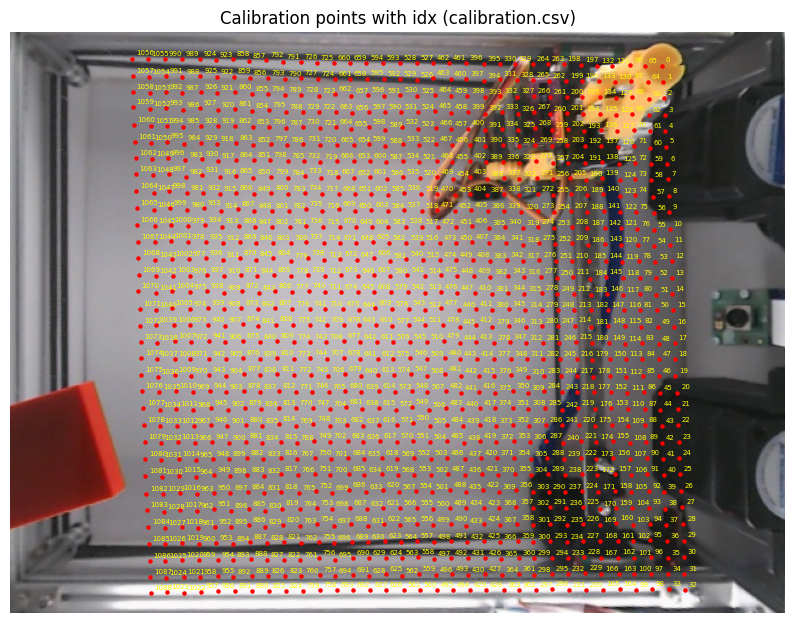

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

df = pd.read_csv(CALIBRATION_CSV)
image_path = df.iloc[0]["image_path"]

img = cv2.imread(str(image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img)

for _, row in df.iterrows():
    u = row["u"]
    v = row["v"]
    idx = int(row["idx"])
    plt.text(u + 3, v - 3, str(idx), fontsize=5, color="yellow")
    plt.scatter([u], [v], s=5, c="red")

plt.title(f"Calibration points with idx ({CALIBRATION_CSV.name})")
plt.axis("off")
plt.show()

In [47]:
OUTPUT_DIR = PROJECT_ROOT / "calibration_data" / ARTIFACT_PREFIX
ARTIFACT_PATHS = make_artifact_paths(OUTPUT_DIR)
CALIBRATION_CSV = ARTIFACT_PATHS["csv"]
LUT_PATH = ARTIFACT_PATHS["lut_pkl"]

dataset = parse_dataset(str(CALIBRATION_CSV), min_confidence=0.0, require_ok=True)
lut = build_bidirectional_lookup(dataset, method="clough_tocher")
meta_path = save_lookup_table(lut, str(LUT_PATH))

print("CALIBRATION_CSV:", CALIBRATION_CSV)
print("LUT_PATH:", LUT_PATH)
print("meta_path:", meta_path)
print(lut.metadata)

CALIBRATION_CSV: /Users/kimsumin/projects/RGMC/calibration_data/robot31/calibration.csv
LUT_PATH: /Users/kimsumin/projects/RGMC/calibration_data/robot31/lut.pkl
meta_path: /Users/kimsumin/projects/RGMC/calibration_data/robot31/lut_metadata.json
{'method': 'clough_tocher', 'num_points': 1089, 'workspace_bounds': {'x_min': 0.0, 'x_max': 1.0, 'y_min': 0.0, 'y_max': 1.0}, 'pixel_bounds': {'u_min': 100.39210747271201, 'u_max': 556.8431001890359, 'v_min': 21.62048698572628, 'v_max': 462.9090019569472}}


In [48]:
import pandas as pd
import numpy as np

CSV_PATH = CALIBRATION_CSV
df = pd.read_csv(CSV_PATH)
df_valid = df.dropna(subset=["x", "y", "u", "v"]).copy()

x_pred_list = []
y_pred_list = []
ok_list = []
err_msg_list = []

for _, row in df_valid.iterrows():
    u, v = float(row["u"]), float(row["v"])
    try:
        x_pred, y_pred = mapper.convert_one(u, v)
        x_pred_list.append(x_pred)
        y_pred_list.append(y_pred)
        ok_list.append(True)
        err_msg_list.append(None)
    except Exception as e:
        x_pred_list.append(np.nan)
        y_pred_list.append(np.nan)
        ok_list.append(False)
        err_msg_list.append(str(e))

df_valid["x_pred"] = x_pred_list
df_valid["y_pred"] = y_pred_list
df_valid["ok_lut"] = ok_list
df_valid["lut_errmsg"] = err_msg_list

df_ok = df_valid[df_valid["ok_lut"]].copy()

xy_pred = df_ok[["x_pred", "y_pred"]].values.astype(float)
xy_gt = df_ok[["x", "y"]].values.astype(float)

err_xy = xy_pred - xy_gt
err_norm = np.linalg.norm(err_xy, axis=1)

df_ok["dx"] = err_xy[:, 0]
df_ok["dy"] = err_xy[:, 1]
df_ok["err"] = err_norm

print("CSV_PATH        :", CSV_PATH)
print("num total valid :", len(df_valid))
print("num mapped ok   :", len(df_ok))
print("num failed      :", len(df_valid) - len(df_ok))

if len(df_ok) > 0:
    print("\nLUT error summary (mapped points only)")
    print(df_ok["err"].describe())
    print("\nmean err  :", df_ok["err"].mean())
    print("median err:", df_ok["err"].median())
    print("max err   :", df_ok["err"].max())

print("\nFailed rows preview:")
display(df_valid.loc[~df_valid["ok_lut"], ["x", "y", "u", "v", "lut_errmsg"]].head(10))

CSV_PATH        : /Users/kimsumin/projects/RGMC/calibration_data/robot31/calibration.csv
num total valid : 1089
num mapped ok   : 1088
num failed      : 1

LUT error summary (mapped points only)
count    1.088000e+03
mean     7.732185e-17
std      2.254614e-16
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.118863e-16
max      6.343834e-15
Name: err, dtype: float64

mean err  : 7.732185422663678e-17
median err: 0.0
max err   : 6.343834181149101e-15

Failed rows preview:


,x,y,u,v,lut_errmsg
1055,0.0,1.0,100.392107,21.620487,"(u=100.392107472712, v=21.62048698572628) is o..."


In [49]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

topk = 20
cand = res_df.head(topk)

IMG_DIR = OUTPUT_DIR / "images"

# 폴더 안 이미지 파일 찾기
image_files = []
for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
    image_files.extend(IMG_DIR.glob(ext))

image_files = sorted(image_files)

if not image_files:
    raise FileNotFoundError(f"이미지 파일이 없습니다: {IMG_DIR}")

IMG_PATH = str(image_files[0])   # 첫 번째 이미지 사용
print("IMG_PATH:", IMG_PATH)

img = cv2.imread(IMG_PATH)
if img is None:
    raise ValueError(f"cv2가 이미지를 읽지 못했습니다: {IMG_PATH}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img)

for _, row in cand.iterrows():
    u = float(row["u"])
    v = float(row["v"])
    idx = int(row["idx"])
    resid = float(row["residual_px"])

    plt.scatter([u], [v], s=40, c="cyan")
    plt.text(u + 5, v - 5, f"{idx} ({resid:.1f})", fontsize=8, color="yellow")

plt.title("Top residual candidates")
plt.axis("off")
plt.show()



NameError: name 'res_df' is not defined

timestamp: 1774434006.4382095

[raw info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[proc info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[pred_raw]
{'ok': True, 'center_uv': (328.6364468864469, 249.97527472527472), 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'contour': array([[[321, 230]],

       [[321, 234]],

       [[320, 235]],

       [[319, 235]],

       [[319, 236]],

       [[313, 242]],

       [[310, 242]],

       [[310, 253]],

       [[313, 253]],

       [[314, 254]],

       [[314, 257]],

       [[315, 258]],

       [[315, 260]],

       [[319, 264]],

       [[320, 264]],

       [[322, 266]],

       [[322, 269]],

       [[338, 269]],

       [[338, 266]],

       [[341, 263]],

       [[345, 263]],

       [

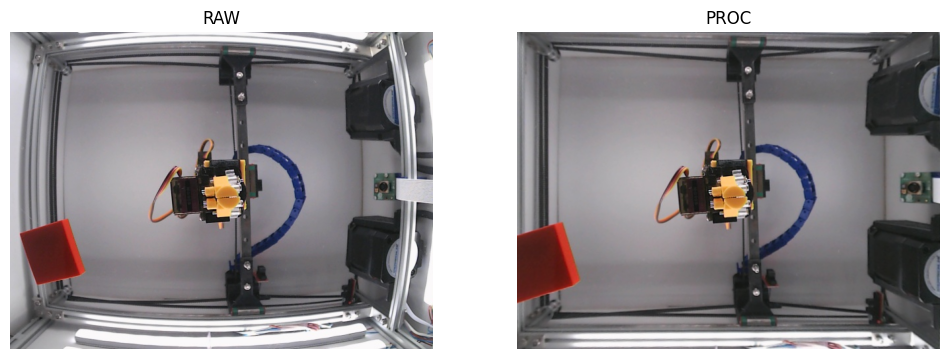

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_raw, ts = robot.getImageBase()
img_proc = get_processed_base_image(robot, K, D, undistort_image)[0]

print("timestamp:", ts)

print("\n[raw info]")
print("type:", type(img_raw))
if isinstance(img_raw, np.ndarray):
    print("shape:", img_raw.shape, "dtype:", img_raw.dtype, "min/max:", img_raw.min(), img_raw.max())

print("\n[proc info]")
print("type:", type(img_proc))
if isinstance(img_proc, np.ndarray):
    print("shape:", img_proc.shape, "dtype:", img_proc.dtype, "min/max:", img_proc.min(), img_proc.max())

pred_raw = detector.predict(img_raw)
pred_proc = detector.predict(img_proc)

print("\n[pred_raw]")
print(pred_raw)

print("\n[pred_proc]")
print(pred_proc)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
if isinstance(img_raw, np.ndarray):
    if img_raw.ndim == 3 and img_raw.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img_raw, cmap="gray")
plt.title("RAW")
plt.axis("off")

plt.subplot(1,2,2)
if isinstance(img_proc, np.ndarray):
    if img_proc.ndim == 3 and img_proc.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img_proc, cmap="gray")
plt.title("PROC")
plt.axis("off")

plt.show()

timestamp: 1774434015.9544857

[raw info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[proc info]
type: <class 'numpy.ndarray'>
shape: (480, 640, 3) dtype: uint8 min/max: 0 255

[pred_raw]
{'ok': True, 'center_uv': (328.67274472168907, 250.81190019193858), 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'contour': array([[[318, 234]],

       [[318, 237]],

       [[313, 242]],

       [[310, 242]],

       [[310, 254]],

       [[313, 254]],

       [[314, 255]],

       [[314, 256]],

       [[315, 257]],

       [[315, 259]],

       [[316, 260]],

       [[316, 261]],

       [[317, 261]],

       [[322, 266]],

       [[322, 269]],

       [[338, 269]],

       [[338, 265]],

       [[339, 264]],

       [[340, 264]],

       [[341, 263]],

       [[345, 263]],

       

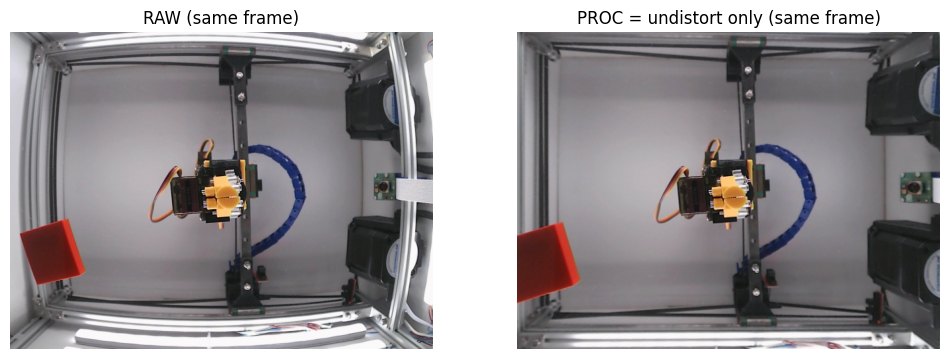

In [51]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_raw, img_proc, ts = get_same_frame_raw_and_proc(robot, K, D, undistort_image)

print("timestamp:", ts)

print("\n[raw info]")
print("type:", type(img_raw))
if isinstance(img_raw, np.ndarray):
    print("shape:", img_raw.shape, "dtype:", img_raw.dtype, "min/max:", img_raw.min(), img_raw.max())

print("\n[proc info]")
print("type:", type(img_proc))
if isinstance(img_proc, np.ndarray):
    print("shape:", img_proc.shape, "dtype:", img_proc.dtype, "min/max:", img_proc.min(), img_proc.max())

pred_raw = detector.predict(img_raw)
pred_proc = detector.predict(img_proc)

print("\n[pred_raw]")
print(pred_raw)

print("\n[pred_proc]")
print(pred_proc)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
if isinstance(img_raw, np.ndarray):
    if img_raw.ndim == 3 and img_raw.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img_raw, cmap="gray")
plt.title("RAW (same frame)")
plt.axis("off")

plt.subplot(1,2,2)
if isinstance(img_proc, np.ndarray):
    if img_proc.ndim == 3 and img_proc.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img_proc, cmap="gray")
plt.title("PROC = undistort only (same frame)")
plt.axis("off")

plt.show()

In [13]:
# 여러 로봇 state 점에서 consistency 측정하는 셀
# calibration / runtime 공통 proc 기준: undistort only
# 각 측정은 same-frame raw -> proc 경로를 사용

import pandas as pd
import numpy as np
import time

test_points = [
(0.173, 0.227),
    (0.417, 0.186),
    (0.731, 0.241),
    (0.284, 0.503),
    (0.563, 0.477),
    (0.812, 0.548),
    (0.146, 0.781),
    (0.488, 0.844),
    (0.733, 0.692),
]

rows = []

for x_cmd, y_cmd in test_points:
    print(f"\nMove to ({x_cmd:.3f}, {y_cmd:.3f})")
    robot.move_xy(x_cmd, y_cmd)
    time.sleep(1.0)

    img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
    pred = detector.predict(img_proc)

    x_state, y_state, ts_state, state = get_state_xy(robot)

    row = {
        "x_cmd": float(x_cmd),
        "y_cmd": float(y_cmd),
        "x_state": float(x_state),
        "y_state": float(y_state),
        "ts_img": ts_img,
        "ts_state": ts_state,
        "dt_state_minus_img": (ts_state - ts_img) if (ts_img is not None and ts_state is not None) else np.nan,
        "ok": bool(pred.get("ok", False)),
    }

    if pred.get("ok") and pred.get("center_uv") is not None:
        u, v = pred["center_uv"]
        x_lut, y_lut = mapper.convert_one(u, v)
        dx = x_lut - x_state
        dy = y_lut - y_state
        err = float(np.hypot(dx, dy))

        row.update({
            "u": float(u),
            "v": float(v),
            "x_lut": float(x_lut),
            "y_lut": float(y_lut),
            "dx": float(dx),
            "dy": float(dy),
            "err": err,
        })
    else:
        row.update({
            "u": np.nan,
            "v": np.nan,
            "x_lut": np.nan,
            "y_lut": np.nan,
            "dx": np.nan,
            "dy": np.nan,
            "err": np.nan,
        })

    rows.append(row)

df_check = pd.DataFrame(rows)
df_check


Move to (0.173, 0.227)

Move to (0.417, 0.186)

Move to (0.731, 0.241)

Move to (0.284, 0.503)

Move to (0.563, 0.477)

Move to (0.812, 0.548)

Move to (0.146, 0.781)

Move to (0.488, 0.844)

Move to (0.733, 0.692)


,x_cmd,y_cmd,x_state,y_state,ts_img,ts_state,dt_state_minus_img,ok,u,v,x_lut,y_lut,dx,dy,err
0,0.173,0.227,0.173214,0.226786,1.774688e+09,1.774688e+09,1.639070,True,473.657558,113.032451,0.172840,0.229213,-0.000374,0.002427,0.002456
1,0.417,0.186,0.416929,0.185500,1.774688e+09,1.774688e+09,1.536737,True,492.798791,220.925734,0.417319,0.185659,0.000390,0.000159,0.000422
2,0.731,0.241,0.731000,0.240500,1.774688e+09,1.774688e+09,1.595136,True,470.424074,359.497222,0.730522,0.239680,-0.000478,-0.000820,0.000949
3,0.284,0.503,0.284357,0.502571,1.774688e+09,1.774688e+09,1.613614,True,350.882979,161.867021,0.283680,0.501323,-0.000677,-0.001248,0.001420
4,0.563,0.477,0.563000,0.476571,1.774688e+09,1.774688e+09,1.621288,True,363.354338,284.940639,0.562485,0.476773,-0.000515,0.000201,0.000553
5,0.812,0.548,0.811929,0.547714,1.774688e+09,1.774688e+09,1.839752,True,333.406469,395.781469,0.812106,0.547000,0.000178,-0.000714,0.000736
6,0.146,0.781,0.146357,0.780571,1.774688e+09,1.774688e+09,1.744970,True,225.968295,100.959726,0.146655,0.782804,0.000297,0.002233,0.002252
7,0.488,0.844,0.488143,0.843500,1.774688e+09,1.774688e+09,1.722070,True,199.589671,251.312676,0.487729,0.843230,-0.000414,-0.000270,0.000494
8,0.733,0.692,0.732929,0.691571,1.774688e+09,1.774688e+09,1.612691,True,268.163283,360.154457,0.733048,0.693976,0.000119,0.002405,0.002408


timestamp: 1774414671.9138966
img_raw : (480, 640, 3) uint8
img_proc: (480, 640, 3) uint8

[pred_raw]
{'ok': True, 'center_uv': (328.8146013448607, 250.92315081652256), 'mask': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'contour': array([[[318, 234]],

       [[318, 237]],

       [[315, 240]],

       [[315, 241]],

       [[313, 243]],

       [[310, 243]],

       [[310, 254]],

       [[313, 254]],

       [[314, 255]],

       [[314, 256]],

       [[315, 257]],

       [[315, 259]],

       [[322, 266]],

       [[322, 269]],

       [[339, 269]],

       [[339, 265]],

       [[341, 263]],

       [[345, 263]],

       [[345, 241]],

       [[342, 241]],

       [[339, 238]],

       [[339, 234]]], dtype=int32), 'score': 0.5449775457382202, 'bbox_xyxy': (313.33416748046875, 234.17926025390625, 345.01312255

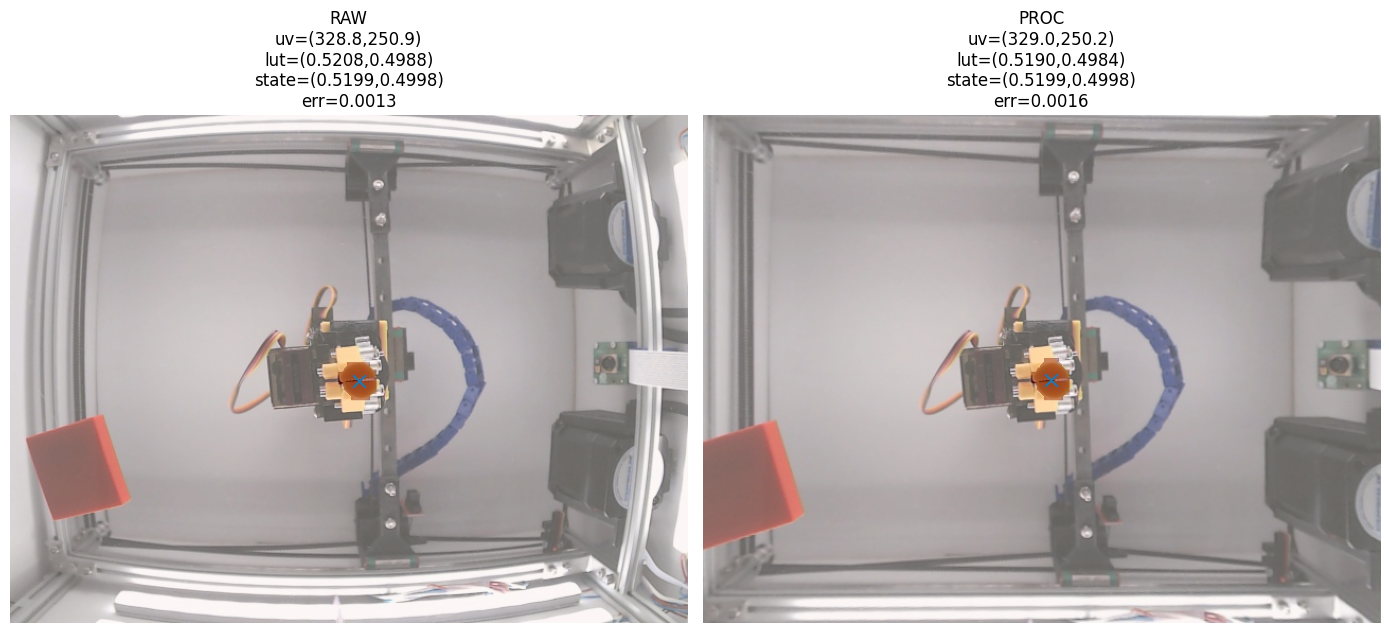

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)
pred = detector.predict(img_proc)

x_state, y_state, ts_state, state = get_state_xy(robot)

print("ts_img:", ts_img)
print("\n[pred]")
print(pred)

print("\n[state]")
print("state:", state)
print("ts_state:", ts_state)

if ts_img is not None and ts_state is not None:
    print("dt_state_minus_img:", ts_state - ts_img)

print(f"x_state = {x_state:.6f}, y_state = {y_state:.6f}")

if not pred.get("ok"):
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    plt.title("Detector failed on current PROC frame")
    plt.axis("off")
    plt.show()
    raise RuntimeError("Detector failed on current frame.")

u, v = pred["center_uv"]
x_lut, y_lut = mapper.convert_one(u, v)

dx = x_lut - x_state
dy = y_lut - y_state
err = float(np.hypot(dx, dy))

print("\n[PROC -> LUT -> STATE]")
print(f"center_uv = ({u:.3f}, {v:.3f})")
print(f"xy_lut    = ({x_lut:.6f}, {y_lut:.6f})")
print(f"dx        = {dx:.6f}")
print(f"dy        = {dy:.6f}")
print(f"err       = {err:.6f}")

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))

if pred.get("mask") is not None:
    plt.imshow(pred["mask"], alpha=0.35, cmap="Reds")

plt.scatter([u], [v], s=80, marker="x")
plt.title(
    f"PROC center=({u:.1f},{v:.1f}) | "
    f"LUT=({x_lut:.4f},{y_lut:.4f}) | "
    f"STATE=({x_state:.4f},{y_state:.4f}) | "
    f"err={err:.4f}"
)
plt.axis("off")
plt.show()

In [21]:
state, timestamp = get_state_with_timestamp(robot)
print(f"state = {state}, time_stamp = {timestamp}")

state = {'x_norm': 0.5198571428571429, 'y_norm': 0.4997857142857143, 'z_norm': 0.09999999999999998, 'rotation': 0, 'claw_norm': 0.0, 'z_current': '-0.03', 'rotation_current': '0.08', 'claw_current': '0.05'}, time_stamp = 1774414366.645823


Generated off-grid test points:
(0.1033, 0.1)
(0.1043, 0.3024)
(0.1, 0.5057)
(0.1031, 0.7034)
(0.1, 0.8994)
(0.2984, 0.1051)
(0.3017, 0.3039)
(0.2993, 0.4967)
(0.3007, 0.6948)
(0.3039, 0.9)
(0.5031, 0.1)
(0.5056, 0.3047)
(0.5033, 0.4963)
(0.4959, 0.7022)
(0.4956, 0.8997)
(0.6967, 0.102)
(0.6992, 0.304)
(0.704, 0.5037)
(0.6986, 0.6975)
(0.7022, 0.8957)
(0.8964, 0.1)
(0.9, 0.302)
(0.9, 0.5034)
(0.8995, 0.7008)
(0.8957, 0.8954)
[1/25] move to (0.1033, 0.1000)
  ok | uv=(530.96, 81.66) | lut=(0.1012, 0.0995) | dx=-0.002112, dy=-0.000518, err=0.002174
[2/25] move to (0.1043, 0.3024)
  ok | uv=(440.48, 83.03) | lut=(0.1050, 0.3010) | dx=0.000731, dy=-0.001408, err=0.001587
[3/25] move to (0.1000, 0.5057)
  ok | uv=(348.85, 80.93) | lut=(0.0999, 0.5054) | dx=-0.000090, dy=-0.000329, err=0.000341
[4/25] move to (0.1031, 0.7034)
  ok | uv=(262.08, 82.11) | lut=(0.1027, 0.7013) | dx=-0.000437, dy=-0.002123, err=0.002168
[5/25] move to (0.1000, 0.8994)
  ok | uv=(173.81, 80.16) | lut=(0.0997, 0.8

,x_cmd,y_cmd,x_state,y_state,ts_img,ts_state,dt_state_minus_img,ok,u,v,x_lut,y_lut,dx,dy,err
0,0.1033,0.1000,0.103286,0.099929,1.774688e+09,1.774688e+09,1.826037,True,530.963093,81.664323,0.101188,0.099482,-0.002112,-0.000518,0.002174
1,0.1043,0.3024,0.104429,0.301857,1.774688e+09,1.774688e+09,1.765941,True,440.484093,83.027515,0.105031,0.300992,0.000731,-0.001408,0.001587
2,0.1000,0.5057,0.100286,0.505071,1.774688e+09,1.774688e+09,1.745775,True,348.853680,80.929084,0.099910,0.505371,-0.000090,-0.000329,0.000341
3,0.1031,0.7034,0.103214,0.702857,1.774689e+09,1.774689e+09,1.636029,True,262.077125,82.107800,0.102663,0.701277,-0.000437,-0.002123,0.002168
4,0.1000,0.8994,0.100143,0.898857,1.774689e+09,1.774689e+09,1.865300,True,173.808550,80.163569,0.099697,0.897798,-0.000303,-0.001602,0.001630
5,0.2984,0.1051,0.298571,0.104929,1.774689e+09,1.774689e+09,1.624820,True,528.069542,168.148768,0.297914,0.107567,-0.000486,0.002467,0.002514
6,0.3017,0.3039,0.301857,0.303286,1.774689e+09,1.774689e+09,1.640250,True,439.997326,169.977718,0.302190,0.302564,0.000490,-0.001336,0.001423
7,0.2993,0.4967,0.299500,0.496143,1.774689e+09,1.774689e+09,1.705057,True,352.951585,168.398768,0.299557,0.497210,0.000257,0.000510,0.000571
8,0.3007,0.6948,0.301000,0.694286,1.774689e+09,1.774689e+09,1.959658,True,265.492729,169.261762,0.300922,0.693892,0.000222,-0.000908,0.000935
9,0.3039,0.9000,0.304000,0.899357,1.774689e+09,1.774689e+09,1.719215,True,174.560337,170.809167,0.304576,0.898362,0.000676,-0.001638,0.001772



===== Off-grid error summary =====
num valid         : 25 / 25
mean err (norm)   : 0.001421
median err (norm) : 0.001423
max err (norm)    : 0.003035
mean err (mm)     : 0.213
median err (mm)   : 0.213
max err (mm)      : 0.455
mean dt_state-img : 1.705 sec
max dt_state-img  : 2.011 sec

Saved: offgrid_error_results.csv


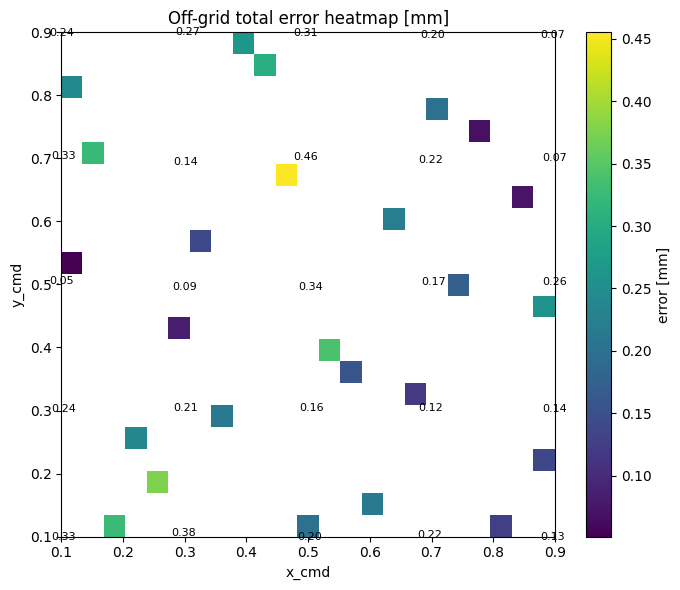

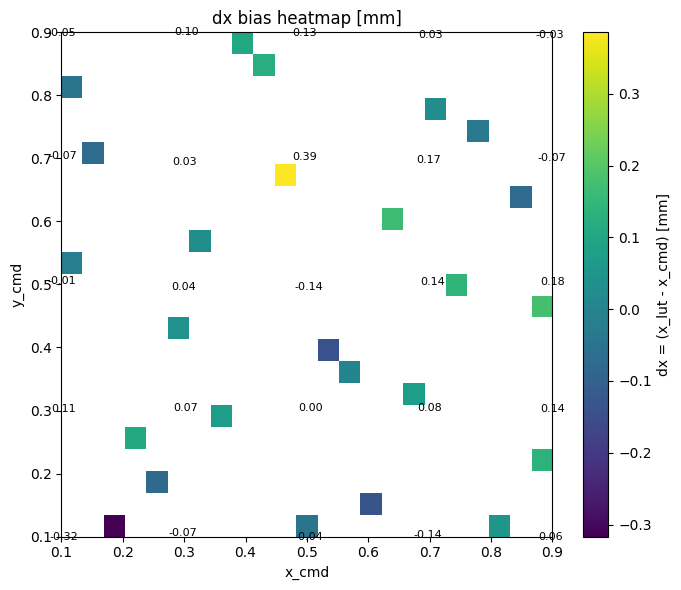

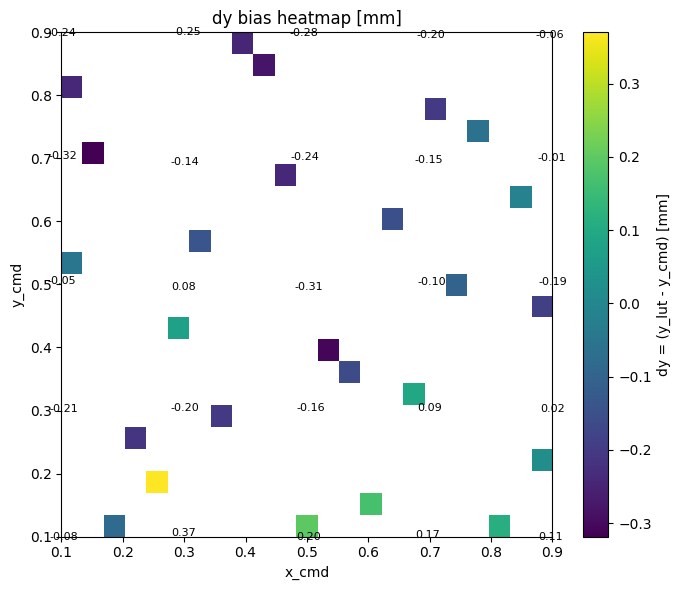

In [14]:
# ============================================
# Off-grid error test + heatmap (single cell)
# Uses notebook variables already defined:
#   robot, detector, mapper, K, D, undistort_image, get_same_frame_raw_and_proc, get_state_xy
# ============================================

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKSPACE_MM = 150.0
GRID_SIZE = 33

def is_near_grid_value(val: float, grid_size: int = GRID_SIZE, tol: float = 0.003) -> bool:
    spacing = 1.0 / (grid_size - 1)
    nearest = round(val / spacing) * spacing
    return abs(val - nearest) < tol

def generate_offgrid_points(
    n_x: int = 5,
    n_y: int = 5,
    x_min: float = 0.10,
    x_max: float = 0.90,
    y_min: float = 0.10,
    y_max: float = 0.90,
    grid_size: int = GRID_SIZE,
    tol_to_grid: float = 0.003,
    jitter: float = 0.006,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    xs = np.linspace(x_min, x_max, n_x)
    ys = np.linspace(y_min, y_max, n_y)
    pts = []

    for x0 in xs:
        for y0 in ys:
            x = float(np.clip(x0 + rng.uniform(-jitter, jitter), x_min, x_max))
            y = float(np.clip(y0 + rng.uniform(-jitter, jitter), y_min, y_max))

            for _ in range(100):
                if (not is_near_grid_value(x, grid_size, tol_to_grid)) and \
                   (not is_near_grid_value(y, grid_size, tol_to_grid)):
                    break
                x = float(np.clip(x0 + rng.uniform(-jitter, jitter), x_min, x_max))
                y = float(np.clip(y0 + rng.uniform(-jitter, jitter), y_min, y_max))

            pts.append((round(x, 4), round(y, 4)))

    return pts

TEST_POINTS = generate_offgrid_points(
    n_x=5,
    n_y=5,
    x_min=0.10,
    x_max=0.90,
    y_min=0.10,
    y_max=0.90,
    grid_size=GRID_SIZE,
    tol_to_grid=0.003,
    jitter=0.006,
    seed=42,
)

print("Generated off-grid test points:")
for p in TEST_POINTS:
    print(p)

rows = []

for i, (x_cmd, y_cmd) in enumerate(TEST_POINTS, start=1):
    print(f"[{i}/{len(TEST_POINTS)}] move to ({x_cmd:.4f}, {y_cmd:.4f})")

    # move
    robot.move_xy(x_cmd, y_cmd)

    # settle
    time.sleep(1.5)

    try:
        # image + preprocess
        img_raw, img_proc, ts_img = get_same_frame_raw_and_proc(robot, K, D, undistort_image)

        # detect
        pred = detector.predict(img_proc)
        u, v = pred["center_uv"]

        # state
        x_state, y_state, ts_state, state = get_state_xy(robot)

        # LUT
        x_lut, y_lut = mapper.convert_one(u, v)

        # command-based error
        dx = x_lut - x_cmd
        dy = y_lut - y_cmd
        err = math.sqrt(dx * dx + dy * dy)

        rows.append({
            "x_cmd": x_cmd,
            "y_cmd": y_cmd,
            "x_state": x_state,
            "y_state": y_state,
            "ts_img": ts_img,
            "ts_state": ts_state,
            "dt_state_minus_img": ts_state - ts_img,
            "ok": True,
            "u": u,
            "v": v,
            "x_lut": x_lut,
            "y_lut": y_lut,
            "dx": dx,
            "dy": dy,
            "err": err,
        })

        print(
            f"  ok | uv=({u:.2f}, {v:.2f}) "
            f"| lut=({x_lut:.4f}, {y_lut:.4f}) "
            f"| dx={dx:.6f}, dy={dy:.6f}, err={err:.6f}"
        )

    except Exception as e:
        rows.append({
            "x_cmd": x_cmd,
            "y_cmd": y_cmd,
            "x_state": np.nan,
            "y_state": np.nan,
            "ts_img": np.nan,
            "ts_state": np.nan,
            "dt_state_minus_img": np.nan,
            "ok": False,
            "u": np.nan,
            "v": np.nan,
            "x_lut": np.nan,
            "y_lut": np.nan,
            "dx": np.nan,
            "dy": np.nan,
            "err": np.nan,
            "errmsg": str(e),
        })
        print(f"  failed | {e}")

df_offgrid = pd.DataFrame(rows)
display(df_offgrid)

df_ok = df_offgrid[df_offgrid["ok"]].copy()

print("\n===== Off-grid error summary =====")
if len(df_ok) > 0:
    err_norm = df_ok["err"].to_numpy()
    err_mm = err_norm * WORKSPACE_MM

    print(f"num valid         : {len(df_ok)} / {len(df_offgrid)}")
    print(f"mean err (norm)   : {np.mean(err_norm):.6f}")
    print(f"median err (norm) : {np.median(err_norm):.6f}")
    print(f"max err (norm)    : {np.max(err_norm):.6f}")
    print(f"mean err (mm)     : {np.mean(err_mm):.3f}")
    print(f"median err (mm)   : {np.median(err_mm):.3f}")
    print(f"max err (mm)      : {np.max(err_mm):.3f}")

    dt = df_ok["dt_state_minus_img"].to_numpy()
    print(f"mean dt_state-img : {np.mean(dt):.3f} sec")
    print(f"max dt_state-img  : {np.max(dt):.3f} sec")
else:
    print("No valid rows.")

# Save CSV
csv_path = "offgrid_error_results.csv"
df_offgrid.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

# -----------------------------
# Heatmaps
# -----------------------------
if len(df_ok) > 0:
    err_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="err").sort_index().sort_index(axis=1)
    dx_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="dx").sort_index().sort_index(axis=1)
    dy_grid = df_ok.pivot(index="y_cmd", columns="x_cmd", values="dy").sort_index().sort_index(axis=1)

    err_mm = err_grid * WORKSPACE_MM
    dx_mm = dx_grid * WORKSPACE_MM
    dy_mm = dy_grid * WORKSPACE_MM

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        err_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            err_mm.columns.min(), err_mm.columns.max(),
            err_mm.index.min(), err_mm.index.max()
        ],
    )
    plt.colorbar(im, label="error [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("Off-grid total error heatmap [mm]")
    for iy, yv in enumerate(err_mm.index):
        for ix, xv in enumerate(err_mm.columns):
            val = err_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        dx_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            dx_mm.columns.min(), dx_mm.columns.max(),
            dx_mm.index.min(), dx_mm.index.max()
        ],
    )
    plt.colorbar(im, label="dx = (x_lut - x_cmd) [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("dx bias heatmap [mm]")
    for iy, yv in enumerate(dx_mm.index):
        for ix, xv in enumerate(dx_mm.columns):
            val = dx_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        dy_mm.values,
        origin="lower",
        aspect="auto",
        extent=[
            dy_mm.columns.min(), dy_mm.columns.max(),
            dy_mm.index.min(), dy_mm.index.max()
        ],
    )
    plt.colorbar(im, label="dy = (y_lut - y_cmd) [mm]")
    plt.xlabel("x_cmd")
    plt.ylabel("y_cmd")
    plt.title("dy bias heatmap [mm]")
    for iy, yv in enumerate(dy_mm.index):
        for ix, xv in enumerate(dy_mm.columns):
            val = dy_mm.iloc[iy, ix]
            if pd.notna(val):
                plt.text(xv, yv, f"{val:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

In [19]:
print("LUT_PATH:", LUT_PATH)

import pandas as pd
df = pd.read_csv("/Users/kimsumin/projects/RGMC/calibration_data/robot6/calibration.csv")
print("CSV sample:")

print(df.head())

LUT_PATH: /Users/kimsumin/projects/RGMC/calibration_data/robot6/lut.pkl
CSV sample:
   idx         x    y           u          v  ok  confidence     std_u  \
0    0  0.000000  0.0  572.360393  37.722420   1         0.0  0.034235   
1    1  0.029687  0.0  573.464764  51.167417   1         0.0  0.335561   
2    2  0.059375  0.0  574.480966  63.258124   1         0.0  0.075077   
3    3  0.089062  0.0  574.716578  76.407308   1         0.0  0.035357   
4    4  0.118750  0.0  575.292487  89.138640   1         0.0  0.060811   

      std_v     timestamp  n_valid  \
0  0.047084  1.774671e+09        5   
1  0.061543  1.774671e+09        5   
2  0.062908  1.774671e+09        5   
3  0.039859  1.774671e+09        5   
4  0.041041  1.774671e+09        5   

                                          image_path  \
0  /Users/kimsumin/projects/RGMC/calibration_data...   
1  /Users/kimsumin/projects/RGMC/calibration_data...   
2  /Users/kimsumin/projects/RGMC/calibration_data...   
3  /Users/kimsumin

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

csv_path = Path(LUT_PATH).parent / "calibration.csv"
df = pd.read_csv(csv_path)

errors = []
failed = []

for i, row in df.iterrows():
    u = row["u"]
    v = row["v"]
    x_gt = row["x"]
    y_gt = row["y"]

    try:
        x_lut, y_lut = mapper.convert_one(u, v)
        err = np.sqrt((x_lut - x_gt)**2 + (y_lut - y_gt)**2)
        errors.append(err)
    except Exception as e:
        failed.append((i, str(e)))

errors = np.array(errors)

print("===== LUT consistency check =====")
print("csv_path :", csv_path)
print("count    :", len(errors))
print("failed   :", len(failed))
if len(errors) > 0:
    print("mean err :", errors.mean())
    print("median   :", np.median(errors))
    print("max err  :", errors.max())

if len(failed) > 0:
    print("\nFirst 5 failures:")
    for item in failed[:5]:
        print(item)

===== LUT consistency check =====
csv_path : /Users/kimsumin/projects/RGMC/calibration_data/robot6/calibration.csv
count    : 1089
failed   : 0
mean err : 4.211848982672594e-17
median   : 0.0
max err  : 1.8906416838689214e-15
